# Detection View — From Data to Alerts

This notebook provides a high-level detection-oriented view of the
CICIDS 2017 dataset.

The purpose is to illustrate how analytical insights might inform
detection intuition, without designing rules, thresholds, or models.

This notebook emphasizes communication and reasoning over computation.


## Why a Detection View?

SOC stakeholders often need intuitive explanations rather than
statistical depth.

This notebook bridges:
- Exploratory analysis
- Feature behavior insights
- SOC alerting and triage thinking

It is designed to be readable by analysts, engineers, and managers.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")


In [2]:
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False


In [3]:
data1 = pd.read_csv(r"D:\MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv")
data2 = pd.read_csv(r"D:\MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv")
data3 = pd.read_csv(r"D:\MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv")
data4 = pd.read_csv(r"D:\MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
data5 = pd.read_csv(r"D:\MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
data6 = pd.read_csv(r"D:\MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv")
data7 = pd.read_csv(r"D:\MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
data8 = pd.read_csv(r"D:\MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

data = pd.concat(
    [data1, data2, data3, data4, data5, data6, data7, data8],
    ignore_index=True
)


In [4]:
# Remove leading/trailing whitespace from column names
data.columns = data.columns.str.strip()

In [5]:
missing_counts = data.isna().sum()
missing_counts[missing_counts > 0]

Flow Bytes/s    1358
dtype: int64

In [6]:
data_before = data.shape[0]
data.dropna(inplace=True)
data_after = data.shape[0]

print(f"Rows before: {data_before}")
print(f"Rows after: {data_after}")

Rows before: 2830743
Rows after: 2829385


In [7]:
dup_before = data.shape[0]
data.drop_duplicates(inplace=True)
dup_after = data.shape[0]

print(f"Rows before duplicate removal: {dup_before}")
print(f"Rows after duplicate removal: {dup_after}")

Rows before duplicate removal: 2829385
Rows after duplicate removal: 2522009


In [8]:
data.columns = (
    data.columns
    .str.encode("ascii", errors="ignore")
    .str.decode("ascii")
)


In [9]:
print("Final cleaned dataset shape:", data.shape)

Final cleaned dataset shape: (2522009, 79)


In [10]:
label_col = 'Label'
normal_data = data[data[label_col] == 'BENIGN']
attack_data = data[data[label_col] != 'BENIGN']


## Candidate Detection Signals (Conceptual)

Based on earlier analysis, the following signals are considered
potential contributors to detection logic:

- Unusually persistent connections
- Asymmetric packet exchange patterns
- Abnormally high traffic volume relative to baseline

These are not rules, but intuition-building signals.


In [11]:
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Length of Fwd Packets'
]


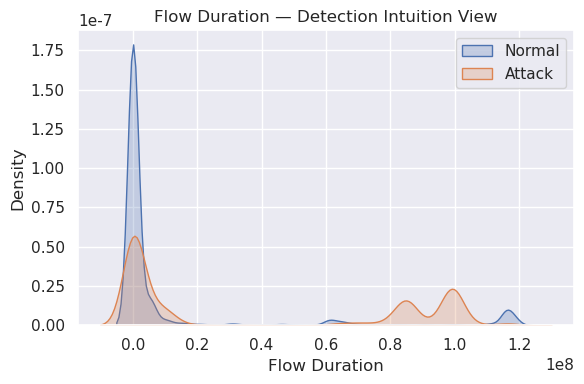

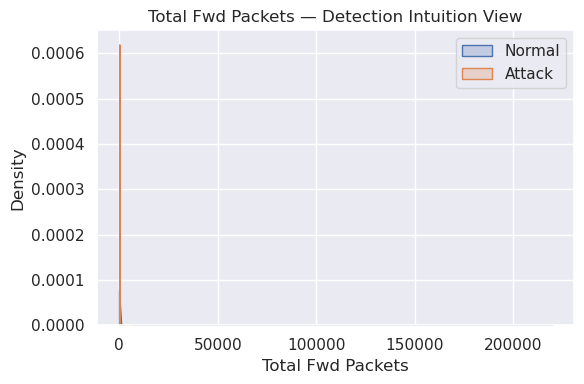

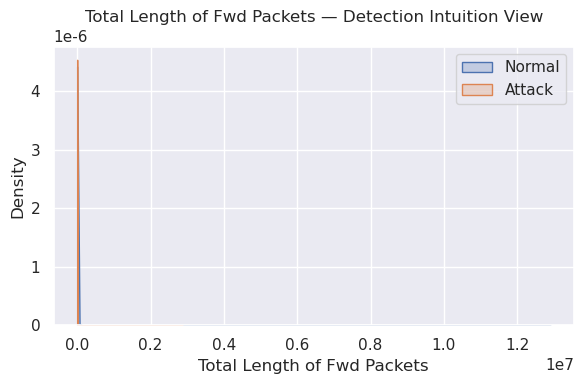

In [12]:
for feature in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(normal_data[feature], label='Normal', fill=True)
    sns.kdeplot(attack_data[feature], label='Attack', fill=True)
    plt.title(f"{feature} — Detection Intuition View")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Why Threshold-Based Detection Breaks

Although visual differences exist, simple thresholds fail because:
- Distributions overlap significantly
- Legitimate behavior can produce extreme values
- Static thresholds ignore time, context, and asset role

Thresholds without context generate excessive false positives.


## Why Context Is Required

Effective detection requires information beyond flow statistics:
- Asset criticality
- Historical behavior
- User intent
- Corroborating alerts

CICIDS 2017 does not provide this context, limiting standalone detection.


## Closing Perspective

This detection view reinforces a key lesson:

Detection is not about finding perfect separators in data.
It is about supporting analysts under uncertainty.

This notebook concludes Phase 3 by connecting analysis, detection
thinking, and SOC workflow considerations.
